# Project II - Music While Studying vs Focus

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

In [44]:
df = pd.read_csv("Music While Studying vs Focus .csv")

## Data cleaning and preperation

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 13 columns):
 #   Column                                                                               Non-Null Count  Dtype 
---  ------                                                                               --------------  ----- 
 0   Timestamp                                                                            61 non-null     object
 1   What is your age group?                                                              61 non-null     object
 2   What is your gender?                                                                 61 non-null     object
 3    How many hours a day do you spend on deep-focus tasks (studying, coding, writing)?  61 non-null     object
 4    How often do you study while listening to music                                     61 non-null     object
 5   What type of music do you usually listen to while studying?                          53 non-null     

In [30]:
df.columns

Index(['Timestamp', 'What is your age group? ', 'What is your gender?  ',
       ' How many hours a day do you spend on deep-focus tasks (studying, coding, writing)?',
       ' How often do you study while listening to music  ',
       'What type of music do you usually listen to while studying?  ',
       'Do you prefer "familiar" or "new" music while working?  ',
       'What kind of tasks do you prefer doing with music?  ',
       'What is your preferred environment for maximum focus?  ',
       'How productive do you feel when studying with music? ',
       ' I often find myself "active listening" (singing/tapping) instead of working  ',
       'Background music prevents me from being distracted by outside noises.  ',
       'Does music reduce your stress while studying?  '],
      dtype='object')

In [29]:
df[df.columns[5]]

,What type of music do you usually listen to while studying?
0,Rap
1,Pop
2,Pop
3,Instrumental
4,My music taste is very diverse. I listen to al...
...,...
56,"Background noise(rain sounds, white noise)"
57,"Background noise(rain sounds, white noise)"
58,Rap
59,Rap


In [32]:
# 1. Handling missing values (column 5) - Filling missing values with 'N/A'
df[df.columns[5]] = df[df.columns[5]].fillna('N/A')

# 2. Renaming columns
new_names = [
    'age_group', 'gender', 'study_hours', 'music_frequency',
    'music_type', 'familiarity', 'preferred_task', 'environment',
    'productivity_score', 'distraction_score', 'focus_shielding_score', 'stress_reduction'
]

rename_map = dict(zip(df.columns[1:13], new_names))

df.rename(columns=rename_map, inplace=True)

# 3. Handling ordinal Data (Ordering categories correctly)
age_order = ['Under 18', '18–21', '21+']
hours_order = ['0–2 hours', '3-5 hours', '6+ hours']
freq_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']

# Converting to categorical types for correct plotting order
df['age_group'] = pd.Categorical(df['age_group'], categories=age_order, ordered=True)
df['study_hours'] = pd.Categorical(df['study_hours'], categories=hours_order, ordered=True)
df['music_frequency'] = pd.Categorical(df['music_frequency'], categories=freq_order, ordered=True)

# weird / not realy an issue fix: حمو المرشدي
# we are changing it because it breaks the plot that's it..
df.loc[6,'music_type'] = "idk"

# to see حمو المرشدي fix
df.head(7)


,Timestamp,age_group,gender,study_hours,music_frequency,music_type,familiarity,preferred_task,environment,productivity_score,distraction_score,focus_shielding_score,stress_reduction
0,2026/04/05 4:58:27 PM GMT+2,NaN,Female,3-5 hours,Often,Rap,Familiar (Songs I’ve heard 100 times),Reading,Total silence (Library/Private room),3,3,3,Yes
1,2026/04/05 5:00:28 PM GMT+2,18–21,Female,0–2 hours,Rarely,Pop,No preference,Solving problems (math/programming),Controlled Audio (Headphones in any environment),4,1,4,No
2,2026/04/05 5:01:11 PM GMT+2,18–21,Female,0–2 hours,Sometimes,Pop,New (Discovering fresh playlists),Writing,Controlled Audio (Headphones in any environment),1,1,1,Maybe
3,2026/04/05 5:16:34 PM GMT+2,18–21,Female,3-5 hours,Sometimes,Instrumental,No preference,Memorization,Controlled Audio (Headphones in any environment),1,2,2,Maybe
4,2026/04/05 5:19:20 PM GMT+2,18–21,Female,6+ hours,Always,My music taste is very diverse. I listen to al...,Familiar (Songs I’ve heard 100 times),Writing,Controlled Audio (Headphones in any environment),4,3,5,Maybe
5,2026/04/05 5:38:01 PM GMT+2,18–21,Female,0–2 hours,Rarely,N/A,New (Discovering fresh playlists),I don’t study with music,Moderate (Coffee shop/Public space),3,5,3,Maybe
6,2026/04/05 6:12:17 PM GMT+2,18–21,Male,0–2 hours,Rarely,idk,Familiar (Songs I’ve heard 100 times),Solving problems (math/programming),Total silence (Library/Private room),3,3,3,Maybe


In [33]:
# Save the cleaned dataframe to a CSV file
df.to_csv('Cleaned_Music_Study_Data.csv', index=False)

## Demographic Analysis - Who took the survey?

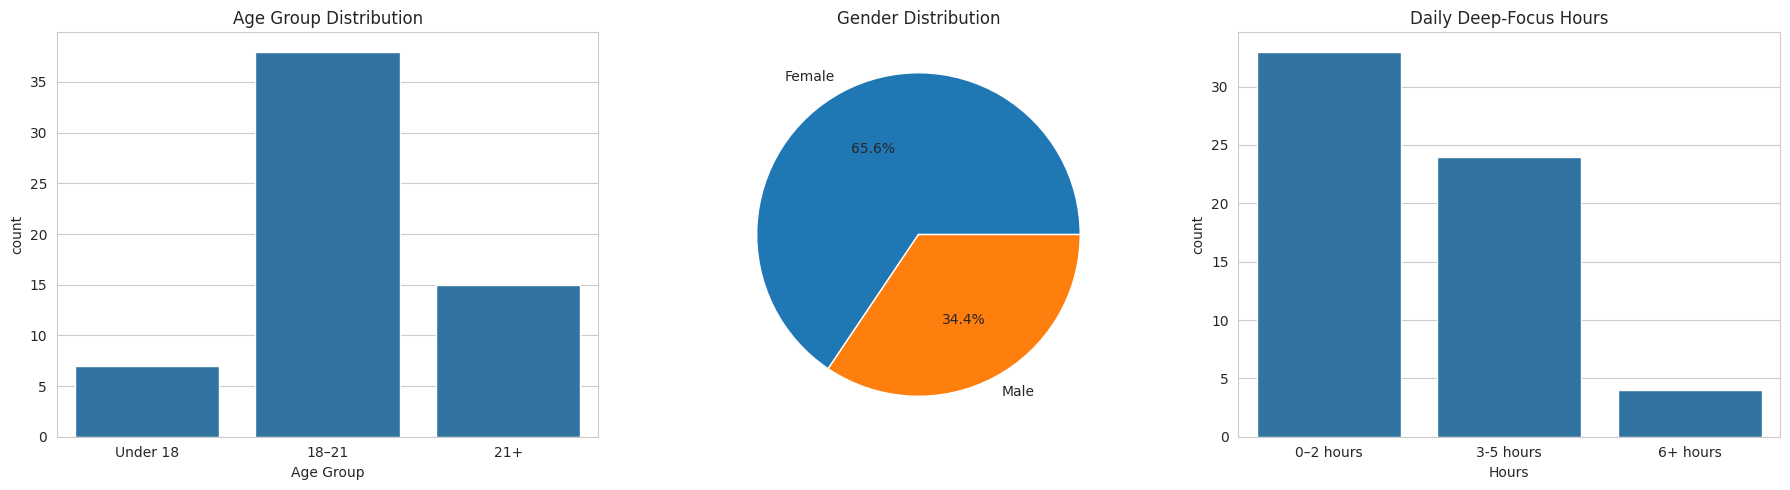

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age Distribution
sns.countplot(data=df, x='age_group', ax=axes[0])
axes[0].set_title('Age Group Distribution')
axes[0].set_xlabel('Age Group')

# Gender Distribution
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Gender Distribution')
axes[1].set_ylabel('')

# Study Hours Distribution
sns.countplot(data=df, x='study_hours', ax=axes[2])
axes[2].set_title('Daily Deep-Focus Hours')
axes[2].set_xlabel('Hours')

plt.tight_layout()
plt.show()

## Music Habits Analysis - What do people listen to and how often?

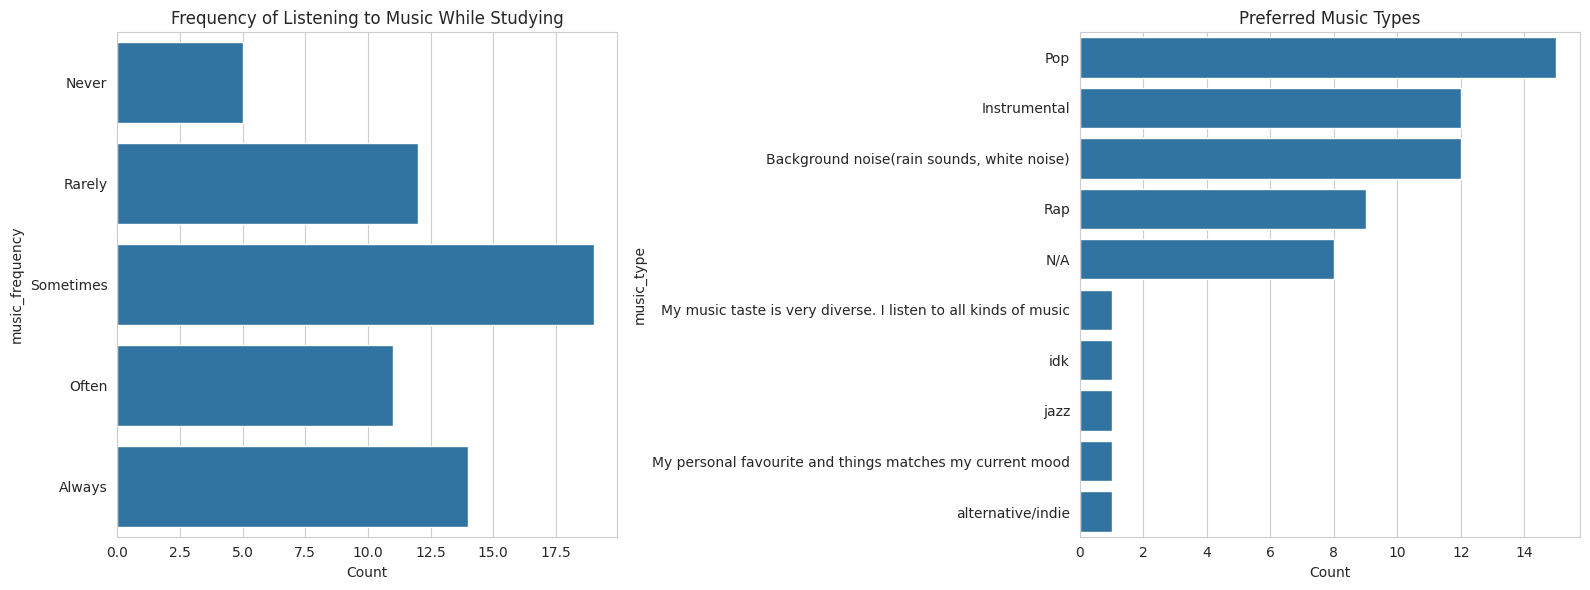

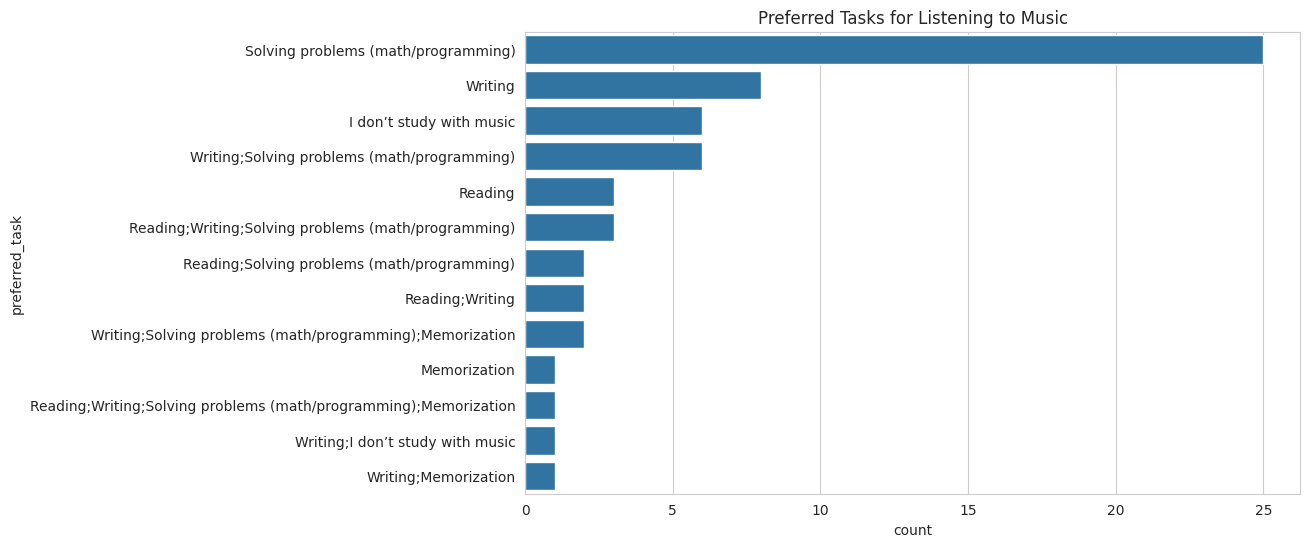

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Music Frequency
sns.countplot(data=df, y='music_frequency', ax=axes[0], order=freq_order)
axes[0].set_title('Frequency of Listening to Music While Studying')
axes[0].set_xlabel('Count')

# Music Type Popularity
sns.countplot(data=df, y='music_type', ax=axes[1], order=df['music_type'].value_counts().index)
axes[1].set_title('Preferred Music Types')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

# Task Preference (Analyzing what tasks music helps with)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='preferred_task', order=df['preferred_task'].value_counts().index)
plt.title('Preferred Tasks for Listening to Music')
plt.show()

## Focus & Productivity Analysis - Does music actually help?

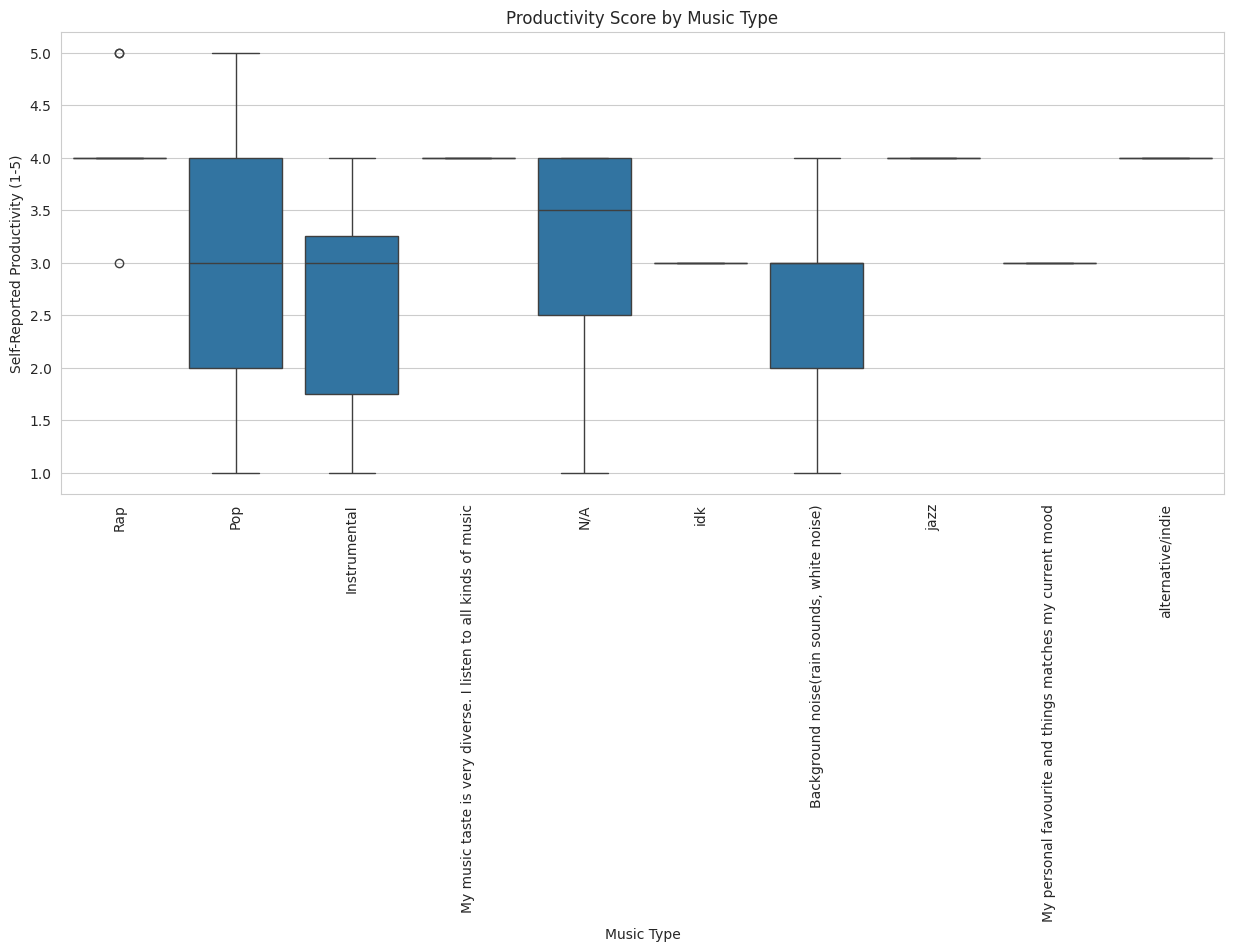

In [36]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df, x='music_type', y='productivity_score')
plt.title('Productivity Score by Music Type')
plt.xlabel('Music Type')
plt.xticks(rotation=90)
plt.ylabel('Self-Reported Productivity (1-5)')
plt.show()

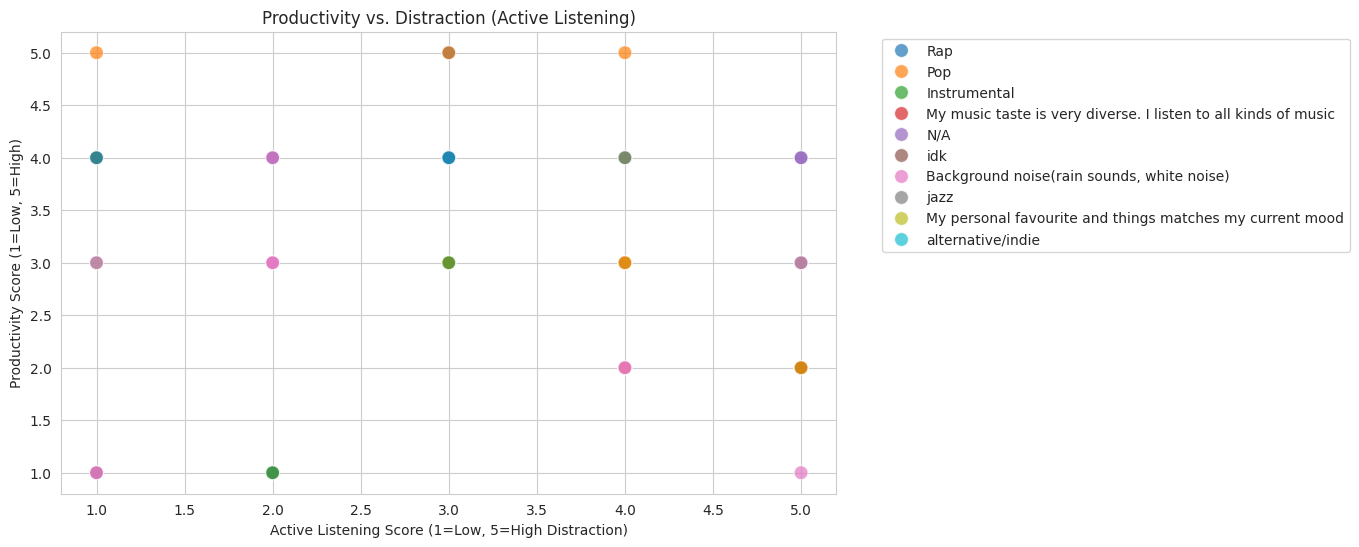

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='distraction_score', y='productivity_score', hue='music_type', s=100, alpha=0.7)
plt.title('Productivity vs. Distraction (Active Listening)')
plt.xlabel('Active Listening Score (1=Low, 5=High Distraction)')
plt.ylabel('Productivity Score (1=Low, 5=High)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

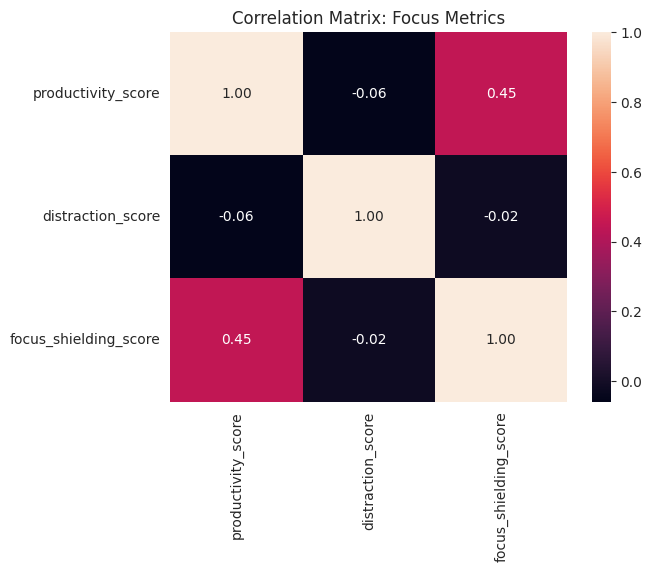

In [38]:
corr_matrix = df[['productivity_score', 'distraction_score', 'focus_shielding_score']].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title('Correlation Matrix: Focus Metrics')
plt.show()

## Hypothesis Testing
### H0: There is no difference in the average distraction score between people who listen to lyrical music and those who listen to non-lyrical music.

### H1: People who listen to lyrical music have a significantly higher average distraction score than those who listen to non-lyrical music.

In [39]:
# Create a new column to categorize music
lyrical_types = ['Pop', 'Rap']
non_lyrical_types = ['Instrumental', 'Background noise']

# Filter the dataframe (excluding 'Other' or undefined types for this specific test)
df_lyrical = df[df['music_type'].isin(lyrical_types)]
df_non_lyrical = df[df['music_type'].isin(non_lyrical_types)]

print(f"Lyrical Music Listeners: {len(df_lyrical)}")
print(f"Non-Lyrical Music Listeners: {len(df_non_lyrical)}")

Lyrical Music Listeners: 24
Non-Lyrical Music Listeners: 12


In [40]:
scores_lyrical = df_lyrical['distraction_score']
scores_non_lyrical = df_non_lyrical['distraction_score']

# Perform T-test
t_stat, p_val = stats.ttest_ind(scores_lyrical, scores_non_lyrical, equal_var=False, alternative='greater')

print(f"T-Test Results: Lyrical vs. Non-Lyrical")
print(f"Mean Distraction (Lyrical): {scores_lyrical.mean():.2f}")
print(f"Mean Distraction (Non-Lyrical): {scores_non_lyrical.mean():.2f}")
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_val:.4f}")

alpha = 0.05
if p_val < alpha:
    print("Result: Statistically Significant!")
    print("We reject H0. Lyrical music causes significantly more distraction.")
else:
    print("Result: Not Significant.")
    print("We FAIL to reject H0. There is no evidence supporting the claim that Lyrical is more distracting.")

T-Test Results: Lyrical vs. Non-Lyrical
Mean Distraction (Lyrical): 3.04
Mean Distraction (Non-Lyrical): 3.00
T-statistic: 0.08
P-value: 0.4666
Result: Not Significant.
We FAIL to reject H0. There is no evidence supporting the claim that Lyrical is more distracting.
